# A Notebook for Classify The Loan_Status (yes, no)
There is a company named Dream Housing Finance that deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan. However doing this manually takes a lot of time. Hence it wants to automate the loan eligibility process (real time) based on customer information.
The above problem is a clear classification problem as we need to classify whether the Loan_Status is yes or no. So this can be solved by Decision Tree Algorithm.

# Description about the Data Columns:

Now let us understand the data columns (that has been already given by the company itself ) first so that we will get a glance:
Loan ID -> As the name suggests each person should have a unique loan ID.
Gender -> In general it is male or female. No offence for not including the third gender.
Married -> Applicant who is married is represented by Y and not married is represented as N. 
Dependents -> the number of people dependent on the applicant who has taken loan has been provided.
Education -> It is either non -graduate or graduate.
Self_Employed -> As the name suggests Self Employed means , he/she is employed for himself/herself only.(Y/N)
Applicant Income -> Applicant Income suggests the income by Applicant.
Co Applicant income -> this represents the income of co-applicant.
Loan Amount -> This amount represents the loan amount in thousands.
Loan_Amount_Term -> This represents the number of months required to repay the loan.
Credit_History -> When I googled it , I got this information. A credit history is a record of a borrower’s responsible repayment of debts. It suggests → 1 denotes that the credit history is good and 0 otherwise.
Property_Area -> The area where they belong to is my general assumption as nothing more is told. Here it can be three types. Urban or Semi Urban or Rural
Loan_Status -> If the applicant is eligible for loan it’s yes represented by Y else it’s no represented by N.



In [24]:
# Importing libraries
import numpy as np
import pandas as pd
desired_width = 320
pd.set_option('display.width', desired_width)
np.set_printoptions(linewidth=desired_width)
pd.set_option('display.max_columns', 21)
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn import metrics
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

# Now I am going to upload or read the files/data-sets using pandas

In [25]:
#///////////////////////////////////Load dataset/////////////////////////////////////
path_file = file_path = 'datasets_15953_21070_train_u6lujuX_CVtuZ9i (1).csv'
data = pd.read_csv(file_path, header=0)
print("Rows number, columns number : ->",data.shape)
print("Columns name :->",(list(data.columns)))
print(data.head())


Rows number, columns number : -> (614, 12)
Columns name :-> ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History Property_Area Loan_Status
0   Male      No          0      Graduate            No             5849                0.0         NaN             360.0             1.0         Urban           Y
1   Male     Yes          1      Graduate            No             4583             1508.0       128.0             360.0             1.0         Rural           N
2   Male     Yes          0      Graduate           Yes             3000                0.0        66.0             360.0             1.0         Urban           Y
3   Male     Yes          0  Not Graduate            No             2583             2358.0   

# Now let us analyse the data using single variable.

In [26]:
print("Numbre of Yes and no in all dataset",data['Loan_Status'].value_counts())
print(data.groupby('Loan_Status').mean())

Numbre of Yes and no in all dataset Y    422
N    192
Name: Loan_Status, dtype: int64
             ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History
Loan_Status                                                                                  
N                5446.078125        1877.807292  151.220994        344.064516        0.541899
Y                5384.068720        1504.516398  144.294404        341.072464        0.981818


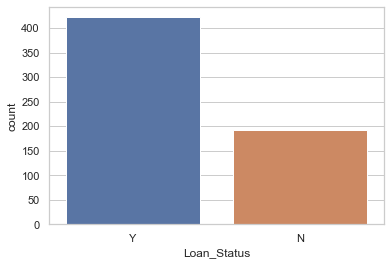

In [27]:
# The percentage of people that the loan has been approved has been higher rather than the percentage of applicant for which the loan has been declined.
sns.countplot(x='Loan_Status', data=data)
plt.show()

Text(0, 0.5, 'Frequency of loan')

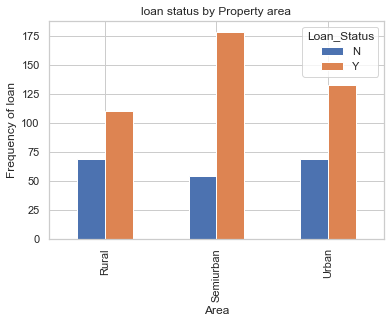

In [28]:
# We can infer that percentage of  people in the Area "Semiurban"  who have got their loan approved is higher when compared to "Urban" and "Rural" area  people.
pd.crosstab(data.Property_Area, data.Loan_Status).plot(kind='bar')
plt.title('loan status by Property area')
plt.xlabel('Area')
plt.ylabel('Frequency of loan')

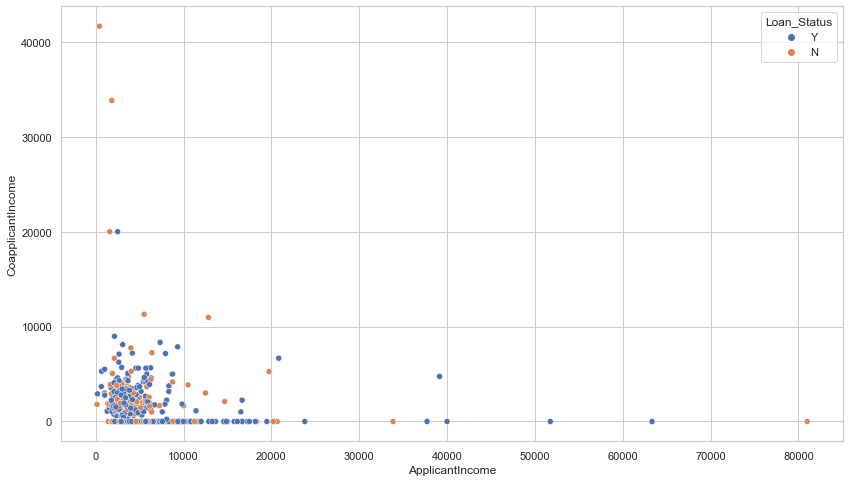

In [29]:
# In the above one I tried to know whether we can segregate the Loan Status based on Applicant Income and CoapplicantIncome.
plt.figure(figsize=(14, 8))
sns.scatterplot(x=data['ApplicantIncome'], y=data['CoapplicantIncome'], hue=data['Loan_Status'])
plt.show()

In [30]:
#///////////////////////////////// spliting datasets/////////////////////////////////////////////////
#Separating target
X = data.iloc[:, data.columns != 'Loan_Status']
y = data.iloc[:, data.columns == 'Loan_Status']


Before we go for modeling the data, we have to check whether the data is cleaned or not. And after cleaning part, we have to structure the Data. For cleaning part, First I have to check whether there exists any missing values. For that I am using the code snippet isnull().

In [31]:
print(data.isnull().sum())

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


The above code suggests that there are 13 missing values in Gender, 3 in Married, 15 in Dependents, 32 in Self_Employed, 22 in Loan Amount, 14 in Loan_Amount_Term and 50 in Credit History.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
from sklearn.preprocessing import LabelEncoder
s = (X.dtypes == 'object')
object_cols = list(s[s].index)
label_X_train = X_train.copy()
label_X_valid = X_test.copy()
label_encoder = LabelEncoder()
for col in object_cols:
    label_X_train[col] = label_encoder.fit_transform(X_train[col].astype(str))
    label_X_valid[col] = label_encoder.transform(X_test[col].astype(str))
# missing value
cols_with_missing = (col for col in X_train.columns if X_train[col].isnull().any())
for col in cols_with_missing:
    label_X_train[col + '_was_missing'] =  label_X_train[col].isnull()
    label_X_valid[col + '_was_missing'] =  label_X_valid[col].isnull()
my_imputer = SimpleImputer()
label_X_train = my_imputer.fit_transform(label_X_train)
label_X_valid = my_imputer.transform(label_X_valid)

As here we wan’t to classify between the people who have taken loan or not we have used Decision Tree.

In [41]:
#Function to perform training with Entropy
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42, min_samples_split=4, max_depth=2, min_samples_leaf=12)
clf_entropy.fit(label_X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=12,
                       min_samples_split=6, random_state=42)

In [42]:
y_pred = clf_entropy.predict(label_X_valid)
print(y_pred)


['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y']


In [43]:
# As we can see average accuracy is 77.83% . I have used the same thing for predicting test data variable.
print ("Accuracy of model ", accuracy_score(y_test,y_pred)*100)


Accuracy is  77.83783783783784
